# Import Libraries

In [ ]:
!pip install pandas numpy scikit-learn tensorflow openpyxl

In [ ]:
!pip install transformers datasets scikit-learn pandas torch

# Dataset Load

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Book1.xlsx to Book1 (1).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("Book1.xlsx")

# rename for safety
df = df.rename(columns={
    "Complaint Text": "text",
    "Category": "label"
})

print(df.head())

  ID                                               text             label
0  1  আমার ফেসবুক আইডি হ্যাক করে পাসওয়ার্ড পরিবর্তন...   Account Hacking
1  2  বিকাশে টাকা পাঠানোর পর প্রতারক আমাকে ব্লক করে ...   Financial Fraud
2  3  অচেনা নাম্বার থেকে আমাকে হুমকি দিয়ে মেসেজ পাঠ...  Cyber Harassment
3  4   আমার জিমেইল অ্যাকাউন্টে ঢুকে সব তথ্য চুরি করেছে।   Account Hacking
4  5  অনলাইনে চাকরির কথা বলে টাকা নিয়ে আর যোগাযোগ ক...       Online Scam


# Data Preprocessing

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation (Bangla + English)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
import re
import string

In [ ]:
df["clean_text"] = df["text"].apply(clean_text)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])

print(list(le.classes_))

['Account Hacking', 'Category', 'Copyright Violation', 'Cyber Abuse', 'Cyber Blackmail', 'Cyber Harassment', 'Cyber Stalking', 'Data Breach', 'Fake Profile', 'Financial Fraud', 'Identity Theft', 'Image Misuse', 'Malware Attack', 'OTP Fraud', 'Online Scam', 'Phishing', 'Romance Scam']


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42
)

# XLM-R

In [ ]:
!pip install transformers datasets accelerate evaluate openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [ ]:
!pip install -U transformers datasets accelerate evaluate
!pip install -U torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 526.6/526.6 MB 137.1 MB/s eta 0:00:01^C


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import evaluate

In [ ]:
df = pd.read_excel("/content/Book1.xlsx")

df = df.rename(columns={
    "Complaint Text":"text",
    "Category":"label"
})

df = df[['text','label']]

df.head()

,text,label
0,আমার ফেসবুক আইডি হ্যাক করে পাসওয়ার্ড পরিবর্তন...,Account Hacking
1,বিকাশে টাকা পাঠানোর পর প্রতারক আমাকে ব্লক করে ...,Financial Fraud
2,অচেনা নাম্বার থেকে আমাকে হুমকি দিয়ে মেসেজ পাঠ...,Cyber Harassment
3,আমার জিমেইল অ্যাকাউন্টে ঢুকে সব তথ্য চুরি করেছে।,Account Hacking
4,অনলাইনে চাকরির কথা বলে টাকা নিয়ে আর যোগাযোগ ক...,Online Scam


In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)

['Account Hacking' 'Category' 'Copyright Violation' 'Cyber Abuse'
 'Cyber Blackmail' 'Cyber Harassment' 'Cyber Stalking' 'Data Breach'
 'Fake Profile' 'Financial Fraud' 'Identity Theft' 'Image Misuse'
 'Malware Attack' 'OTP Fraud' 'Online Scam' 'Phishing' 'Romance Scam']


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,

    random_state=42
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

1200
150
150


In [ ]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids","attention_mask","label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids","attention_mask","label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids","attention_mask","label"]
)

In [ ]:
num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],

        "precision": precision.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["precision"],

        "recall": recall.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["recall"],

        "f1": f1.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["f1"]
    }

In [ ]:
training_args = TrainingArguments(

    output_dir="./xlmr",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_steps=20,

    report_to="none"
)

In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    #tokenizer=tokenizer,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.285896,1.934834,0.406667,0.196373,0.406667,0.257654
2,1.529295,1.245715,0.693333,0.631756,0.693333,0.624535
3,1.040099,0.971040,0.733333,0.667536,0.733333,0.677883
4,0.925190,0.793967,0.800000,0.735722,0.800000,0.753328
5,0.804498,0.739487,0.806667,0.743706,0.806667,0.763941


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=1.3982038599650064, metrics={'train_runtime': 847.8173, 'train_samples_per_second': 7.077, 'train_steps_per_second': 0.442, 'total_flos': 394719736320000.0, 'train_loss': 1.3982038599650064, 'epoch': 5.0})

In [ ]:
val_result = trainer.evaluate()

print(val_result)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.804498,0.739487,5,0.806667,0.743706,0.806667,0.763941


{'eval_loss': 0.7394868731498718, 'eval_accuracy': 0.8066666666666666, 'eval_precision': 0.7437056462056463, 'eval_recall': 0.8066666666666666, 'eval_f1': 0.7639408576438705}


In [ ]:
test_result = trainer.evaluate(test_dataset)

print(test_result)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.804498,0.584690,5,0.826667,0.808090,0.826667,0.805852


{'eval_loss': 0.584689736366272, 'eval_accuracy': 0.8266666666666667, 'eval_precision': 0.8080901771336554, 'eval_recall': 0.8266666666666667, 'eval_f1': 0.8058518503553893}


# BanglaBERT

In [ ]:
from transformers import AutoTokenizer

model_name =  "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

In [ ]:
import torch

class CyberDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CyberDataset(train_encodings, train_labels)
test_dataset = CyberDataset(test_encodings, test_labels)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
)

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    logging_steps=1,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='weighted'
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.035965,1.340675,0.736667,0.650914,0.736667,0.654655
2,1.087776,0.830446,0.846667,0.796592,0.846667,0.815306
3,0.743583,0.684846,0.866667,0.815666,0.866667,0.836310


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=225, training_loss=1.2891081068250867, metrics={'train_runtime': 75.5069, 'train_samples_per_second': 47.678, 'train_steps_per_second': 2.98, 'total_flos': 29603980224000.0, 'train_loss': 1.2891081068250867, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()

print("Accuracy:", results["eval_accuracy"])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.743583,0.684846,3,0.866667,0.815666,0.866667,0.836310


Accuracy: 0.8666666666666667


# model save

In [ ]:
from transformers import AutoTokenizer

hf_tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")

trainer.save_model("./banglabert_cyber_model")
hf_tokenizer.save_pretrained("./banglabert_cyber_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./banglabert_cyber_model/tokenizer_config.json',
 './banglabert_cyber_model/tokenizer.json')

In [ ]:
logs = trainer.state.log_history

In [ ]:
for log in trainer.state.log_history:
    print(log)

{'loss': 2.006811319986979, 'grad_norm': 2.101215362548828, 'learning_rate': 3.355555555555556e-05, 'epoch': 1.0, 'step': 75}
{'eval_loss': 1.337327241897583, 'eval_accuracy': 0.5933333333333334, 'eval_precision': 0.46244001419542996, 'eval_recall': 0.5933333333333334, 'eval_f1': 0.500129104148352, 'eval_runtime': 0.2935, 'eval_samples_per_second': 1022.194, 'eval_steps_per_second': 64.739, 'epoch': 1.0, 'step': 75}
{'loss': 1.060306905110677, 'grad_norm': 5.339354515075684, 'learning_rate': 1.688888888888889e-05, 'epoch': 2.0, 'step': 150}
{'eval_loss': 0.8508793115615845, 'eval_accuracy': 0.7833333333333333, 'eval_precision': 0.7869591670376297, 'eval_recall': 0.7833333333333333, 'eval_f1': 0.7481126144558393, 'eval_runtime': 0.7745, 'eval_samples_per_second': 387.349, 'eval_steps_per_second': 24.532, 'epoch': 2.0, 'step': 150}
{'loss': 0.72548583984375, 'grad_norm': 1.7045769691467285, 'learning_rate': 2.2222222222222224e-07, 'epoch': 3.0, 'step': 225}
{'eval_loss': 0.71186429262161

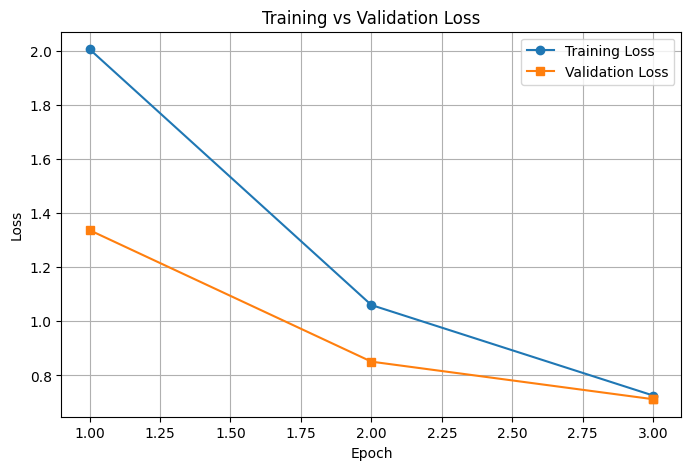

In [ ]:
import matplotlib.pyplot as plt

train_loss = []
eval_loss = []
epochs_train = []
epochs_eval = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        epochs_train.append(log["epoch"])

    if "eval_loss" in log and "epoch" in log:
        eval_loss.append(log["eval_loss"])
        epochs_eval.append(log["epoch"])

plt.figure(figsize=(8, 5))
plt.plot(epochs_train, train_loss, marker='o', label='Training Loss')
plt.plot(epochs_eval, eval_loss, marker='s', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

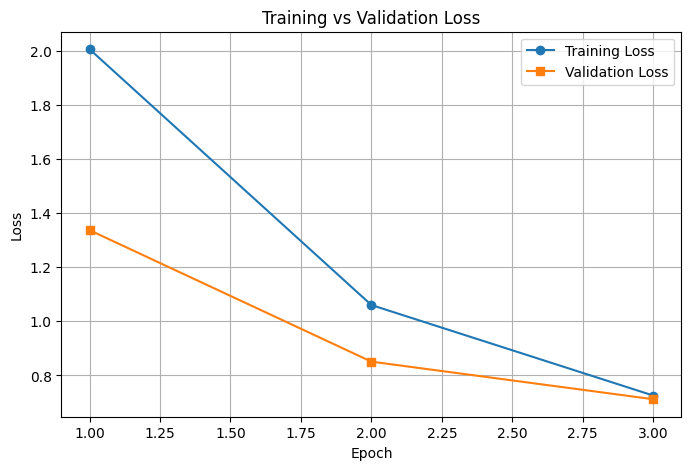

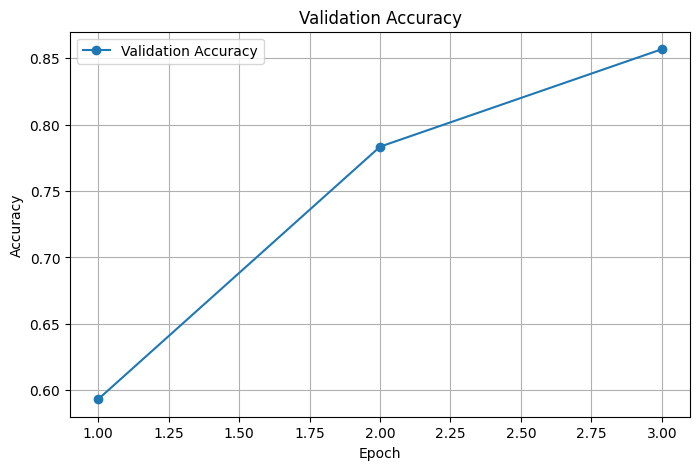

In [ ]:
import matplotlib.pyplot as plt

# Example data
epochs = [1, 2, 3]

train_loss = [2.006811, 1.060307, 0.725486]
val_loss = [1.337327, 0.850879, 0.711864]

# যদি training accuracy না থাকে,
# Trainer log history থেকে collect করতে হবে
val_acc = [0.593333, 0.783333, 0.856667]

# -----------------------------
# LOSS CURVE
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='s', label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# ACCURACY CURVE
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# confussion matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


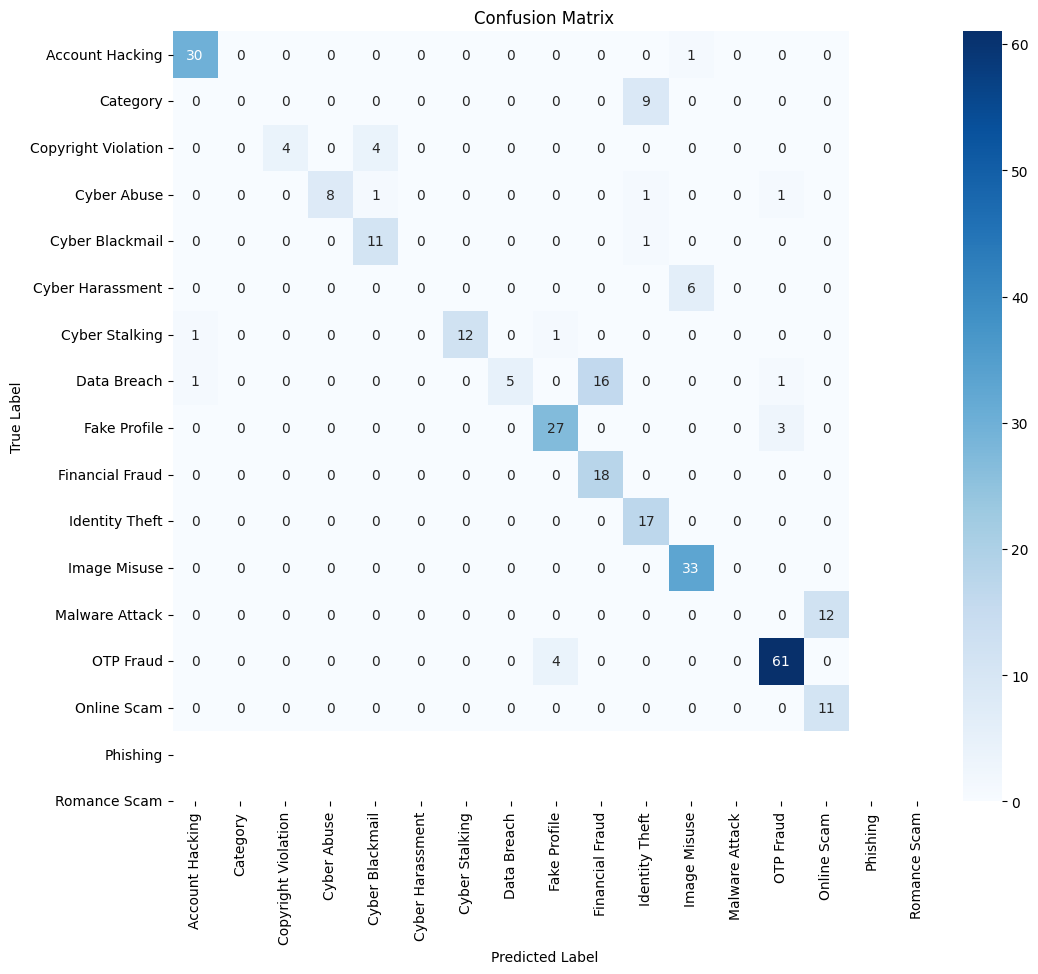

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test dataset
predictions = trainer.predict(test_dataset)

# Convert logits to class labels
y_pred_classes = np.argmax(predictions.predictions, axis=1)

# True labels
y_true = predictions.label_ids

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()



In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # move inputs to GPU
    inputs = {key: value.to(device) for key, value in inputs.items()}

    # prediction
    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    return le.inverse_transform([pred])[0]

print(predict("আমার ফেসবুক হ্যাক হয়ে গেছে"))

Account Hacking


# BiLSTM

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

In [ ]:
df = pd.read_excel("Book1.xlsx")

df = df.rename(columns={
    "Complaint Text": "text",
    "Category": "label"
})

df = df.dropna()
df = df.drop_duplicates()

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"[^\u0980-\u09FF\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)

In [ ]:
texts = df["text"].tolist()
labels = df["label"].tolist()

In [ ]:
le = LabelEncoder()
labels = le.fit_transform(labels)

print("Classes:", le.classes_)

Classes: ['Account Hacking' 'Category' 'Copyright Violation' 'Cyber Abuse'
 'Cyber Blackmail' 'Cyber Harassment' 'Cyber Stalking' 'Data Breach'
 'Fake Profile' 'Financial Fraud' 'Identity Theft' 'Image Misuse'
 'Malware Attack' 'OTP Fraud' 'Online Scam' 'Phishing' 'Romance Scam']


In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,

)

In [ ]:
vocab_size = 20000
max_len = 100
embedding_dim = 128

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_seq = tokenizer.texts_to_sequences(train_texts)
test_seq = tokenizer.texts_to_sequences(test_texts)

train_pad = pad_sequences(train_seq, maxlen=max_len, padding="post")
test_pad = pad_sequences(test_seq, maxlen=max_len, padding="post")

In [ ]:
model = Sequential()

# 🔹 Word Embedding layer (START HERE)
model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))

# 🔹 BiLSTM layer
model.add(Bidirectional(LSTM(64, return_sequences=False)))

# 🔹 Dropout (overfitting control)
model.add(Dropout(0.5))

# 🔹 Dense layers
model.add(Dense(32, activation="relu"))

# output layer
model.add(Dense(len(le.classes_), activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_pad,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.1990 - loss: 2.6570 - val_accuracy: 0.2672 - val_loss: 2.5644
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3353 - loss: 2.2962 - val_accuracy: 0.3879 - val_loss: 1.9958
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5469 - loss: 1.5775 - val_accuracy: 0.6034 - val_loss: 1.3276
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6899 - loss: 1.1182 - val_accuracy: 0.6379 - val_loss: 1.0360
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7459 - loss: 0.8518 - val_accuracy: 0.7759 - val_loss: 0.8154
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8126 - loss: 0.6340 - val_accuracy: 0.8534 - val_loss: 0.6368
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8783 - loss: 0.4335 - val_accuracy: 0.8707 - val_loss: 0.5410
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9063 - loss: 0.3591 - val_accuracy: 0.8966 - 

In [ ]:
loss, acc = model.evaluate(test_pad, test_labels)
print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8924 - loss: 0.4177
Test Accuracy: 0.8923611044883728


# model save

In [ ]:
model.save("bilstm_cyber_model.keras")

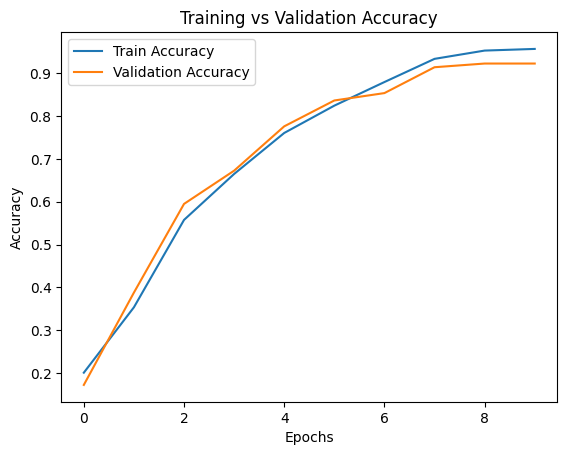

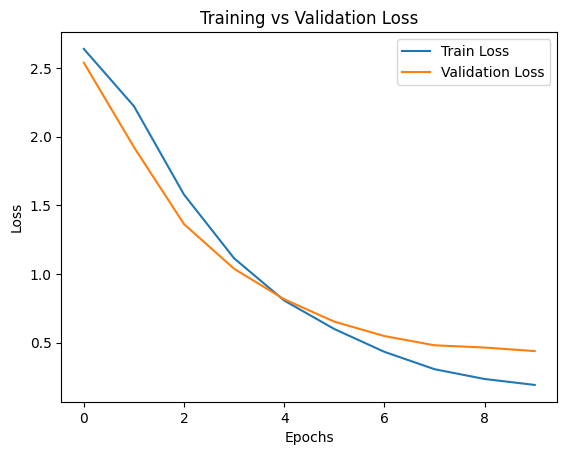

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


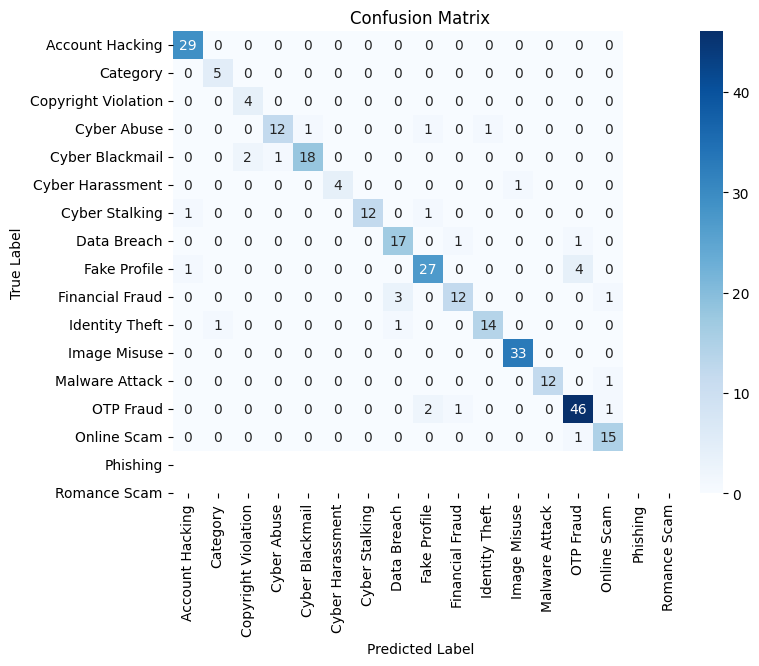

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
y_pred = model.predict(test_pad)

# Convert to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# sample testing

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 128

def predict(text):
    # text → sequence
    seq = tokenizer.texts_to_sequences([text])

    # padding
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    # prediction
    pred_probs = model.predict(padded, verbose=0)

    # class index
    pred_class = np.argmax(pred_probs, axis=1)[0]

    # convert number → text label
    return classes[pred_class]

In [ ]:
classes = sorted(df["label"].unique())
print(classes)

['Account Hacking', 'Category', 'Copyright Violation', 'Cyber Abuse', 'Cyber Blackmail', 'Cyber Harassment', 'Cyber Stalking', 'Data Breach', 'Fake Profile', 'Financial Fraud', 'Identity Theft', 'Image Misuse', 'Malware Attack', 'OTP Fraud', 'Online Scam', 'Phishing', 'Romance Scam']


In [ ]:
print(predict("আমার ফেসবুক হ্যাক হয়ে গেছে"))

Account Hacking


# END